In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import figure
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
import numpy as np
from sklearn.ensemble import RandomForestClassifier
import os
import joblib

In [2]:
PROCESSED_DIR = "../dataset/processed"

if not os.path.exists(PROCESSED_DIR):
    raise FileNotFoundError(f"Directory {PROCESSED_DIR} not found. Please run preprocess_pipeline.ipynb first.")

print("Loading X data (Features)...")
X_train = pd.read_parquet(f"{PROCESSED_DIR}/X_train.parquet")
X_val = pd.read_parquet(f"{PROCESSED_DIR}/X_val.parquet")
X_test = pd.read_parquet(f"{PROCESSED_DIR}/X_test.parquet")

print("Loading y data (Labels)...")
y_train = pd.read_parquet(f"{PROCESSED_DIR}/y_train.parquet")['label']
y_val = pd.read_parquet(f"{PROCESSED_DIR}/y_val.parquet")['label']
y_test = pd.read_parquet(f"{PROCESSED_DIR}/y_test.parquet")['label']

print("\n--- Data Shapes ---")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}, y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")

Loading X data (Features)...
Loading y data (Labels)...

--- Data Shapes ---
X_train: (432395, 162), y_train: (432395,)
X_val:   (54049, 162), y_val:   (54049,)
X_test:  (54050, 162), y_test:  (54050,)


In [3]:
print("Loading Preprocessing Artifacts...")

# Load Label Encoder
le = joblib.load(f"{PROCESSED_DIR}/label_encoder.joblib")
print("\nLabel mapping (class -> encoded):")
for cls in le.classes_:
    print(f"  {cls} -> {int(le.transform([cls])[0])}")

# Load Preprocessing Info (Zero variance cols and High correlation cols that were dropped)
preprocessing_info = joblib.load(f"{PROCESSED_DIR}/preprocessing_info.joblib")
print("\nPreprocessing Info:")
print(f"  Zero-variance columns dropped:     {len(preprocessing_info['zero_var_cols'])}")
print(f"  Highly-correlated columns dropped: {len(preprocessing_info['high_corr_cols'])}")
print(f"  Final feature columns count:       {len(preprocessing_info['feature_columns'])}")

Loading Preprocessing Artifacts...

Label mapping (class -> encoded):
  Attack -> 0
  Benign -> 1
  Suspicious -> 2

Preprocessing Info:
  Zero-variance columns dropped:     3
  Highly-correlated columns dropped: 152
  Final feature columns count:       162


In [4]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

tune_rf = RandomForestClassifier(
    class_weight="balanced_subsample", # Explicitly handle imbalance natively (better than sample_weight for CV)
    random_state=42,
    n_jobs=-1
)

param_distributions = {
    "n_estimators": [100, 300, 500],
    "max_depth": [6, 10, 20, None],
    "min_samples_split": [2, 5, 10]
}

print("[RF] Starting RandomizedSearchCV...")
search = RandomizedSearchCV(tune_rf, param_distributions, n_iter=3, scoring='f1_macro', cv=3, random_state=42, n_jobs=1, verbose=2)
search.fit(X_train, y_train) 

model = search.best_estimator_
print(f"[RF] Best Hyperparameters: {search.best_params_}")

val_pred = model.predict(X_val)
print(f"[Val] Macro F1: {f1_score(y_val, val_pred, average='macro'):.4f}")

[RF] Starting RandomizedSearchCV...
Fitting 3 folds for each of 3 candidates, totalling 9 fits
[CV] END max_depth=None, min_samples_split=10, n_estimators=500; total time=  32.3s
[CV] END max_depth=None, min_samples_split=10, n_estimators=500; total time=  31.1s
[CV] END max_depth=None, min_samples_split=10, n_estimators=500; total time=  34.1s
[CV] END max_depth=10, min_samples_split=5, n_estimators=300; total time=  16.7s
[CV] END max_depth=10, min_samples_split=5, n_estimators=300; total time=  16.1s
[CV] END max_depth=10, min_samples_split=5, n_estimators=300; total time=  17.5s
[CV] END max_depth=20, min_samples_split=10, n_estimators=500; total time=  30.2s
[CV] END max_depth=20, min_samples_split=10, n_estimators=500; total time=  33.0s
[CV] END max_depth=20, min_samples_split=10, n_estimators=500; total time=  31.7s
[RF] Best Hyperparameters: {'n_estimators': 500, 'min_samples_split': 10, 'max_depth': None}
[Val] Macro F1: 0.8872



=== Classification Report ===
              precision    recall  f1-score   support

      Attack     0.9676    0.9479    0.9576     17044
      Benign     0.9878    0.9857    0.9867     34918
  Suspicious     0.6465    0.7778    0.7061      2088

    accuracy                         0.9657     54050
   macro avg     0.8673    0.9038    0.8835     54050
weighted avg     0.9683    0.9657    0.9667     54050



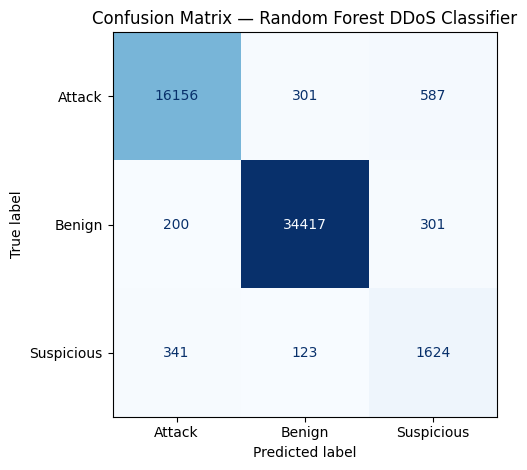

In [5]:
y_pred = model.predict(X_test)
y_pred_labels = le.inverse_transform(y_pred)
y_test_labels = le.inverse_transform(y_test)

print("\n=== Classification Report ===")
print(classification_report(y_test_labels, y_pred_labels, digits=4))

cm = confusion_matrix(y_test_labels, y_pred_labels, labels=le.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', colorbar=False)
plt.title("Confusion Matrix — Random Forest DDoS Classifier")
plt.tight_layout()
plt.savefig("random_forest_confusion_matrix.png", dpi=150)
plt.show()

In [6]:
f1_macro = f1_score(y_test_labels, y_pred_labels, average="macro")
f1_weighted = f1_score(y_test_labels, y_pred_labels, average="weighted")

print(f"F1 (macro): {f1_macro:.4f}")
print(f"F1 (weighted): {f1_weighted:.4f}")

F1 (macro): 0.8835
F1 (weighted): 0.9667


In [7]:
import pickle

model_filename = 'random_forest_model.pkl'
with open(model_filename, 'wb') as f:
    pickle.dump(model, f)
print(f"[Output] Trained model saved to '{model_filename}'")

[Output] Trained model saved to 'random_forest_model.pkl'


In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

try:
    y_true_for_metrics = y_test_labels
    y_pred_for_metrics = y_pred_labels
except NameError:
    y_true_for_metrics = y_test
    if 'y_pred_encoded' in locals():
        y_pred_for_metrics = y_pred_encoded
    elif 'y_pred' in locals():
        y_pred_for_metrics = y_pred

accuracy = accuracy_score(y_true_for_metrics, y_pred_for_metrics)
precision = precision_score(y_true_for_metrics, y_pred_for_metrics, average='weighted')
recall = recall_score(y_true_for_metrics, y_pred_for_metrics, average='weighted')
f1 = f1_score(y_true_for_metrics, y_pred_for_metrics, average='weighted')

try:
    if hasattr(model, 'predict_proba'):
        y_pred_proba = model.predict_proba(X_test)
        roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')
        roc_auc_str = f"{roc_auc:.4f}"
    else:
        # Some models like LinearSVC don't have predict_proba but might have decision_function
        if hasattr(model, 'decision_function'):
            y_pred_decision = model.decision_function(X_test)
            roc_auc = roc_auc_score(y_test, y_pred_decision, multi_class='ovr', average='weighted')
            roc_auc_str = f"{roc_auc:.4f}"
        else:
            roc_auc_str = "N/A (predict_proba not available)"
except Exception as e:
    roc_auc_str = f"N/A ({e})"

print("--- Classification Metrics ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}\n")
print("--- ROC-AUC ---")
print(f"ROC-AUC Score: {roc_auc_str}")


--- Classification Metrics ---
Accuracy:  0.9657
Precision: 0.9683
Recall:    0.9657
F1-score:  0.9667

--- ROC-AUC ---
ROC-AUC Score: 0.9983
